In [2]:
from lorenzo_utils import *
from visualization_utils import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [8]:
graph_path = DATA_DIR + '\climate_23.graphml'
G = load_graph(graph_path)

In [11]:
G.vs['degree'] = G.degree()

In [5]:
def mixing_matrix(G: ig.Graph, 
                  partition: np.ndarray | None = None, 
                  normalized: bool = True):
    
    
    
    edgelist = G.get_edgelist()

    if partition is not None:
        
        q = 2
        M = np.zeros((q, q))
        labels = list(range(q))
        for u, v in edgelist:
            r, s = partition[u], partition[v]
            M[r, s] += 1
            if r != s:
                M[s, r] += 1
    
    # calcolo la matrice di mixing senza confrontarla con nessuna partizione 
    else:
        labels = sorted(set(G.vs['group'])) # [A, B]
        label_idx = {l: i for i, l in enumerate(labels)} # {'A': 0, 'B': 1}
        n = len(labels)
        M = np.zeros((n, n))

        for u, v in edgelist:
            r = label_idx[G.vs[u]['group']]
            s = label_idx[G.vs[v]['group']]
            if r == s:
                M[r, r] += 1
            else:
                M[r, s] += 1
                M[s, r] += 1    
    
    if normalized:
        M = M / M.sum()

    return M, labels


def plot_mixing_matrix(G, M, labels, title=''):

    
    fig, ax = plt.subplots(figsize=(5, 4))

    im = ax.imshow(M, cmap=CMAP_HEAT, vmin=0, vmax=M.max())
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=13)
    ax.set_yticklabels(labels, fontsize=13)
    ax.set_xlabel('Gruppo', fontsize=12)
    ax.set_ylabel('Gruppo', fontsize=12)
    ax.set_title('Mixing matrix' + title)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f'{M[i,j]:.3f}',
                    ha='center', va='center',
                    color='white' if M[i,j] > M.max()*0.6 else 'black',
                    fontsize=10)

    plt.colorbar(im, ax=ax, label='Frazione di archi')
    plt.tight_layout()
    plt.show()

In [9]:
def log_likelihood_score(G: ig.Graph, partition: np.ndarray, q: int, degree_corrected: bool=True):

    degree = np.array(G.vs['degree'])

    # matrice di mixing -> conteggio degli archi tra gruppi (Lrs)
    L, _ = mixing_matrix(G, partition=partition, normalized=False)

    # kr somma dei gradi di tutti i nodi nel gruppo r
    k = np.zeros(q)
    for i, r in enumerate(partition):
        k[r] += degree[i]

    # per SBM non-DC il denominatore è il numero di nodi per blocco, non la somma dei gradi
    n_r = np.bincount(partition, minlength=q).astype(float)
    denom = k if degree_corrected else n_r

    # log-likelihood
    log_likelihood = 0
    for r in range(q):
        for s in range(q):
            if L[r, s] > 0 and denom[r] > 0 and denom[s] > 0:
                log_likelihood += L[r][s] * np.log( L[r][s] / (denom[r] * denom[s]) )

    if degree_corrected:
        correction = np.sum(degree[degree > 0] * np.log(degree[degree > 0]))
        log_likelihood -= correction

    return log_likelihood, L, k
    
def count_edges_to_blocks(i: int, partition: np.ndarray, q: int,
                           adjacency: list) -> np.ndarray:
    
    m = np.zeros(q, dtype=int)
    for nb in adjacency[i]: # scorro sui vicini del nodo i
        m[partition[nb]] += 1
    return m

def delta_log_likelihood(i: int, old_block: int,
                         new_block: int,
                         L: np.ndarray,
                         k: np.ndarray,
                         m: np.ndarray,
                         degree: np.ndarray,
                         q: int,
                         block_sizes: np.ndarray,
                         degree_corrected: bool = True
                         ) -> float:
    """
    Calcola ΔLL = LL_new - LL_old quando il nodo i si sposta da old_block a new_block.

    Parametri
    ---------
    m      : count_edges_to_blocks(i, partition, q, adjacency)
    degree : array dei gradi di tutti i nodi
    """
    # non svuotare mai un blocco
    if block_sizes[old_block] <= 1:
        return -np.inf

    r, s = old_block, new_block
    ki = degree[i]

    # --- Costruisci L' localmente ------------------------------------------
    L_new = L.copy()
    L_new[r, r] -= m[r]
    L_new[s, s] += m[s]
    L_new[r, s] += m[r] - m[s]
    L_new[s, r] = L_new[r, s]
    # Aggiornamento archi verso tutti gli altri blocchi t
    for t in range(q):
        if t != r and t != s:
            L_new[r, t] -= m[t]
            L_new[t, r] -= m[t]
            L_new[s, t] += m[t]
            L_new[t, s] += m[t]

    # denominatore: gradi (DC-SBM) o conteggio nodi (SBM)
    if degree_corrected:
        d_new = k.copy()
        d_new[r] -= ki
        d_new[s] += ki
        d_old = k
    else:
        d_new = block_sizes.copy().astype(float)
        d_new[r] -= 1
        d_new[s] += 1
        d_old = block_sizes.astype(float)

    # --- Somma solo le righe r e s (cattura anche i termini simmetrici) ----
    def row_contrib(L_mat, d_vec, row):
        total = 0.0
        for t in range(q):
            if L_mat[row, t] > 0 and d_vec[row] > 0 and d_vec[t] > 0:
                total += L_mat[row, t] * np.log(L_mat[row, t] /
                                                 (d_vec[row] * d_vec[t]))
        return total

    delta = 0.0
    for row in (r, s):
        delta += row_contrib(L_new, d_new, row) - row_contrib(L, d_old, row)

    return delta
def fit_sbm(G: ig.Graph, partition: np.ndarray, q: int, max_iter: int = 100, seed: int = None, degree_corrected: bool = True):
    """
    Fitta uno Stochastic Block Model seguendo l'algoritmo greedy:
      1. Inizializzazione casuale
      2. Per ogni nodo in ordine random: sposta nel blocco che massimizza Δℓ
      3. Ripeti finché nessun miglioramento
 
    Returns
    -------
    partition     : np.ndarray  assegnazione finale dei nodi ai blocchi
    log_lik       : float       log-likelihood finale
    """
    if seed is not None:
        np.random.seed(seed)
 
    n = G.vcount()
    degree = np.array(G.vs['degree'])
 
    # Lista di adiacenza come array numpy 
    adjacency = [np.array(G.neighbors(i)) for i in range(n)]
    block_size = np.bincount(partition, minlength=q)
 
    # --- 1. Inizializzazione ------------------------------------------------
    
    ll, L, k = log_likelihood_score(G, partition, q, degree_corrected)
    print(f"[init] log-likelihood Degree-Corrected={degree_corrected} = {ll:.4f}")
 
    # --- 2. Ottimizzazione --------------------------------------------------
    for iteration in range(max_iter):
        improved = False
        order = np.random.permutation(n)
        m_moved = 0
        for i in order:
            old_block = partition[i]
 
            # Conta gli archi di i verso ogni blocco  (O(deg(i)))
            m = count_edges_to_blocks(i, partition, q, adjacency)
 
            best_delta = 0.0
            best_block = old_block
 
            for new_block in range(q):
                if new_block == old_block:
                    continue
                if block_size[old_block] <=1:
                    continue
 
                # FIX CRITICO: calcolo incrementale, nessuna copia di partition
                d = delta_log_likelihood(i, old_block, new_block,
                                         L, k, m, degree, q, block_size,
                                         degree_corrected)
                if d > best_delta:
                    best_delta = d
                    best_block = new_block
 
            # Applica lo spostamento solo se c'è un miglioramento reale
            if best_block != old_block:
                m_moved += 1
                block_size[old_block] -= 1
                block_size[best_block] += 1
                # Aggiorna L e k in-place  (O(q))
                r, s = old_block, best_block
                ki = degree[i]
                L[r, r] -= m[r]
                L[s, s] += m[s]
                L[r, s] += m[r] - m[s]
                L[s, r] = L[r, s]  # maintain symmetry (was a no-op)
                for t in range(q):
                    if t != r and t != s:
                        L[r, t] -= m[t]
                        L[t, r] -= m[t]
                        L[s, t] += m[t]
                        L[t, s] += m[t]
                k[r] -= ki
                k[s] += ki
                partition[i] = best_block      # FIX: aggiorna solo dopo la scelta
                improved = True
 
        ll_new, _, _ = log_likelihood_score(G, partition, q, degree_corrected)
        print(f"[iter {iteration+1}] nodi spostati: {m_moved}/{n}  "
      f"log-likelihood = {ll_new:.4f}  (Δ = {ll_new - ll:+.4f})")
        ll = ll_new
 
        if not improved:
            print(f"Convergenza raggiunta all'iterazione {iteration+1}.")
            break
        
    
    return partition, ll
def multiple_restart(G: ig.Graph, K: int = 2, n_restarts: int = 10, degree_corrected: bool = True):
    
    n = G.vcount()
    best_ll = -np.inf
    best_partition = None

    if degree_corrected:
        print("Fit della rete reale con Degree Corrected Stochastic Block Model")
    else:
        print("Fit della rete reale con Stochastic Block Model")    
    
    
    for restart in range(n_restarts):
        print(f"\n--- Restart {restart+1}/{n_restarts} ---")
        
        partition = np.random.randint(0, K, size=n)
        partition, ll = fit_sbm(G, partition=partition, q=K, max_iter=50, seed=restart, degree_corrected=degree_corrected)
        
        print(f"  log-likelihood finale: {ll:.4f}")
        
        if ll > best_ll:
            best_ll = ll
            best_partition = partition.copy()
    
    print(f"\n=== Miglior log-likelihood: {best_ll:.4f} ===")
    return best_partition, best_ll


In [12]:
final_partition, best_log_likelihood = multiple_restart(G, n_restarts=5, degree_corrected=False)

Fit della rete reale con Stochastic Block Model

--- Restart 1/5 ---
[init] log-likelihood Degree-Corrected=False = -400476.1348
[iter 1] nodi spostati: 5059/11264  log-likelihood = -324743.3234  (Δ = +75732.8114)
[iter 2] nodi spostati: 1656/11264  log-likelihood = -295475.7167  (Δ = +29267.6067)
[iter 3] nodi spostati: 419/11264  log-likelihood = -290608.0908  (Δ = +4867.6258)
[iter 4] nodi spostati: 181/11264  log-likelihood = -288566.4739  (Δ = +2041.6170)
[iter 5] nodi spostati: 76/11264  log-likelihood = -287865.8328  (Δ = +700.6411)
[iter 6] nodi spostati: 9/11264  log-likelihood = -287787.5859  (Δ = +78.2469)
[iter 7] nodi spostati: 0/11264  log-likelihood = -287787.5859  (Δ = +0.0000)
Convergenza raggiunta all'iterazione 7.
  log-likelihood finale: -287787.5859

--- Restart 2/5 ---
[init] log-likelihood Degree-Corrected=False = -401230.3180
[iter 1] nodi spostati: 4955/11264  log-likelihood = -353964.9945  (Δ = +47265.3236)
[iter 2] nodi spostati: 1630/11264  log-likelihood = 

[5793 5471]
AMI: 0.3885
ARI: 0.3304


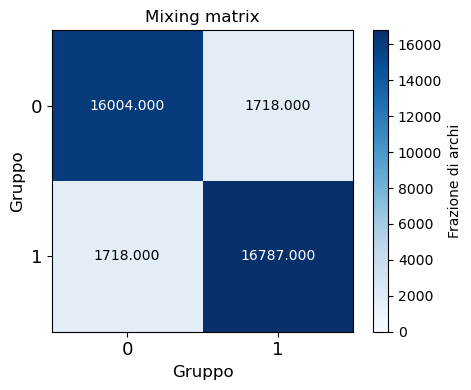

In [13]:
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

true_labels = np.array([0 if v == 'A' else 1 for v in G.vs['group']])

ami = adjusted_mutual_info_score(true_labels, final_partition)
ari = adjusted_rand_score(true_labels, final_partition)

print(np.bincount(final_partition))
print(f"AMI: {ami:.4f}")  # 0 = random, 1 = perfetto
print(f"ARI: {ari:.4f}")  # può essere negativo se peggio del random

M, labels = mixing_matrix(G, partition=final_partition, normalized=False)
plot_mixing_matrix(G, M, labels)